In [1]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "outputs" / "motif_matrix_numeric_v0_1.csv"
TOP_PAIRS_PATH = PROJECT_ROOT / "outputs" / "top_cosine_similarity_pairs_v0_1.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Data path exists:", DATA_PATH.exists())
print("Top pairs path exists:", TOP_PAIRS_PATH.exists())

Project root: c:\Users\zhowa\Documents\GitHub\FloodMyth
Data path exists: True
Top pairs path exists: True


In [2]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
df[["story_id", "story_name", "story_type", "include_in_core_analysis"]]

(12, 74)


,story_id,story_name,story_type,include_in_core_analysis
0,FM-001,Genesis Flood / Noah,survivor-ark flood,yes
1,FM-002,Gilgamesh Tablet XI / Utanapishtim,secret-warning ark flood,yes
2,FM-003,Atrahasis Flood,noise-cause survivor flood,yes
3,FM-004,Eridu Genesis / Ziusudra,king-priest secret-warning flood,yes
4,FM-005,Deucalion and Pyrrha,survivor-chest flood,yes
5,FM-006,Manu and the Fish,animal-helper ritual-recreation flood,yes
6,FM-007,Yu Controls the Flood,flood-control civilization-restoration myth,no
7,FM-008,Popol Vuh / Destruction of the Wooden People,failed-creation destruction flood,no
8,FM-009,Huarochirí / The Llama Warns of the Flood,animal-warning mountain-refuge flood,caution
9,FM-010,Nahui Atl / Tata and Nene,world-age flood with survivor transformation,no


In [3]:
metadata_cols = [
    "story_id",
    "story_name",
    "culture",
    "region",
    "primary_source",
    "source_type",
    "story_type",
    "overall_confidence",
    "source_caution",
    "notes",
    "include_in_core_analysis",
    "analysis_group",
    "recommended_first_visual",
    "score_notes",
]

score_cols = [
    "present_motif_score",
    "uncertain_or_partial_count",
    "core_survivor_package_score",
    "expanded_flood_catastrophe_score",
]

metadata_cols = [col for col in metadata_cols if col in df.columns]
score_cols = [col for col in score_cols if col in df.columns]

motif_cols = [
    col for col in df.columns
    if col not in metadata_cols and col not in score_cols
]

print("Motif columns:", len(motif_cols))

Motif columns: 56


In [4]:
motif_groups = {
    "Cause": [
        "moral_cause",
        "noise_or_overpopulation_cause",
        "failed_creation_cause",
        "primordial_or_cosmic_disorder",
        "world_age_cycle",
        "divine_decision_to_flood_or_destroy",
        "council_or_multiple_deities",
        "flood_as_natural_or_sea_overflow",
        "blood_flood",
        "flood_control_governance_problem",
    ],
    "Warning + Survivor": [
        "chosen_survivor_or_group",
        "survivor_righteous_pious_religious",
        "survivor_is_king_priest_ruler",
        "survivor_couple",
        "family_or_household_saved",
        "animal_or_supernatural_helper_warning",
        "divine_or_supernatural_warning",
        "warning_secret_indirect_wall",
        "dream_warning",
        "specific_warning_timing",
    ],
    "Vessel + Refuge": [
        "boat_or_vessel",
        "non_boat_container_or_tree_chest_vessel",
        "construction_instructions",
        "specific_vessel_dimensions",
        "pitch_or_waterproofing",
        "food_stored_or_rationed",
        "animals_preserved_or_co_survive",
        "civilization_knowledge_or_craftsmen_preserved",
        "mountain_landing_or_refuge",
        "waters_recede_or_subside",
    ],
    "Catastrophe": [
        "storm_or_rain",
        "water_from_above_and_below_or_cosmic_sources",
        "sea_lake_overflow",
        "totalizing_flood_language",
        "regional_flood_language",
        "humanity_destroyed_or_reset",
        "nonhuman_or_giant_population_destroyed",
        "animals_or_objects_rebel",
        "transformation_after_catastrophe",
        "bird_test",
    ],
    "Aftermath": [
        "post_flood_sacrifice_or_offering",
        "divine_smells_or_accepts_offering",
        "post_flood_offering_misdirected_or_inverted",
        "divine_regret_grief_conflict_after_flood",
        "survivor_reward_or_blessing",
        "covenant_promise_or_rainbow",
        "immortality_or_godlike_reward",
        "new_rules_or_order_after_flood",
        "population_control_after_flood",
        "humanity_restored_after_flood",
        "ritual_recreation_after_flood",
        "stones_bones_blood_or_material_recreation",
        "civilization_restored_after_flood",
        "hydraulic_engineering_or_public_works",
        "animal_body_or_species_origin_motif",
        "source_biblical_influence_caution",
    ],
}

ordered_motif_cols = [
    motif
    for group in motif_groups.values()
    for motif in group
    if motif in motif_cols
]

missing_motifs = sorted(set(motif_cols) - set(ordered_motif_cols))

print("Ordered motif columns:", len(ordered_motif_cols))
print("Missing motifs:", missing_motifs)

Ordered motif columns: 56
Missing motifs: []


In [5]:
story_label_map = {
    "Genesis Flood / Noah": "Genesis\nNoah",
    "Gilgamesh Tablet XI / Utanapishtim": "Gilgamesh\nUtanapishtim",
    "Atrahasis Flood": "Atrahasis",
    "Eridu Genesis / Ziusudra": "Eridu Genesis\nZiusudra",
    "Deucalion and Pyrrha": "Deucalion\nPyrrha",
    "Manu and the Fish": "Manu\nFish",
    "Yu Controls the Flood": "Yu\nControls Flood",
    "Popol Vuh / Destruction of the Wooden People": "Popol Vuh\nWooden People",
    "Huarochirí / The Llama Warns of the Flood": "Huarochirí\nLlama",
    "Nahui Atl / Tata and Nene": "Nahui Atl\nTata + Nene",
    "Bergelmir and the Blood Flood": "Bergelmir\nBlood Flood",
    "Nuʻu and the Hawaiian Flood": "Nuʻu\nHawaiian Flood",
}

df["short_label"] = df["story_name"].map(story_label_map).fillna(df["story_name"])
df[["story_name", "short_label"]]

,story_name,short_label
0,Genesis Flood / Noah,Genesis\nNoah
1,Gilgamesh Tablet XI / Utanapishtim,Gilgamesh\nUtanapishtim
2,Atrahasis Flood,Atrahasis
3,Eridu Genesis / Ziusudra,Eridu Genesis\nZiusudra
4,Deucalion and Pyrrha,Deucalion\nPyrrha
5,Manu and the Fish,Manu\nFish
6,Yu Controls the Flood,Yu\nControls Flood
7,Popol Vuh / Destruction of the Wooden People,Popol Vuh\nWooden People
8,Huarochirí / The Llama Warns of the Flood,Huarochirí\nLlama
9,Nahui Atl / Tata and Nene,Nahui Atl\nTata + Nene


In [6]:
# 0 = absent, 0.5 = partial, 1 = present, NaN = uncertain/ambiguous
barcode_cmap = ListedColormap([
    "#101820",  # absent
    "#F2A900",  # partial
    "#00E5FF",  # present
])

barcode_cmap.set_bad("#5A5F66")  # unclear / ambiguous / NaN

barcode_norm = BoundaryNorm(
    boundaries=[-0.1, 0.25, 0.75, 1.1],
    ncolors=barcode_cmap.N,
)

legend_handles = [
    Patch(facecolor="#00E5FF", label="Present"),
    Patch(facecolor="#F2A900", label="Partial"),
    Patch(facecolor="#101820", label="Absent"),
    Patch(facecolor="#5A5F66", label="Unclear / ambiguous"),
]

In [7]:
def make_motif_barcode(
    plot_df,
    title,
    subtitle,
    output_path,
    figsize=(10.8, 19.2),
):
    matrix = plot_df[ordered_motif_cols].astype(float).to_numpy()
    labels = plot_df["short_label"].tolist()

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("#050816")
    ax.set_facecolor("#050816")

    ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap=barcode_cmap,
        norm=barcode_norm,
    )

    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=13, color="white", fontweight="bold")

    ax.set_xticks([])

    # Group boundaries and labels
    start = 0
    for group_name, group_cols in motif_groups.items():
        valid_cols = [col for col in group_cols if col in ordered_motif_cols]
        if not valid_cols:
            continue

        end = start + len(valid_cols)
        center = start + (len(valid_cols) - 1) / 2

        ax.axvline(start - 0.5, color="#FFFFFF", linewidth=0.8, alpha=0.35)

        ax.text(
            center,
            -1.25,
            group_name,
            ha="center",
            va="center",
            fontsize=10,
            color="#E5E7EB",
            fontweight="bold",
        )

        start = end

    ax.axvline(len(ordered_motif_cols) - 0.5, color="#FFFFFF", linewidth=0.8, alpha=0.35)

    # Thin horizontal separators
    for row in range(len(labels) + 1):
        ax.axhline(row - 0.5, color="#FFFFFF", linewidth=0.5, alpha=0.12)

    ax.set_title(title, fontsize=26, color="white", fontweight="bold", pad=50)

    ax.text(
        0.5,
        1.035,
        subtitle,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=13,
        color="#CBD5E1",
    )

    ax.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=4,
        frameon=False,
        fontsize=11,
        labelcolor="white",
    )

    ax.text(
        0.5,
        -0.135,
        "Each row = one flood story/version • Each column = one coded motif",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        color="#94A3B8",
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    return output_path

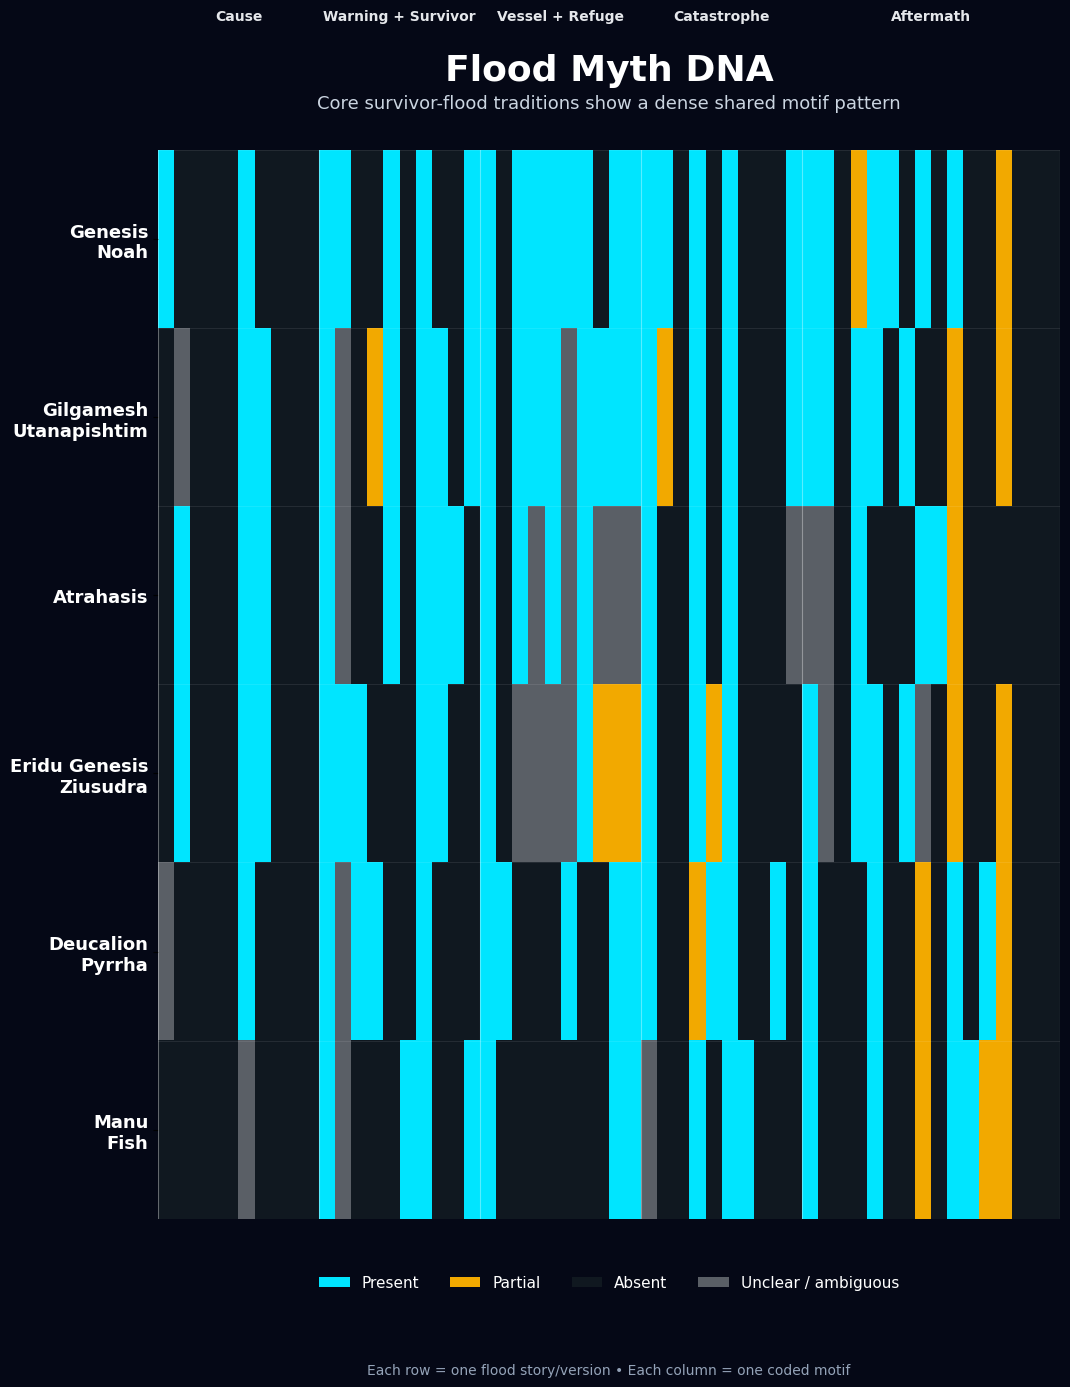

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/youtube_core_motif_barcode_v0_1.png')

In [8]:
core_df = df[df["include_in_core_analysis"].str.lower() == "yes"].copy()

core_barcode_path = OUTPUT_DIR / "youtube_core_motif_barcode_v0_1.png"

make_motif_barcode(
    plot_df=core_df,
    title="Flood Myth DNA",
    subtitle="Core survivor-flood traditions show a dense shared motif pattern",
    output_path=core_barcode_path,
    figsize=(10.8, 14.0),
)

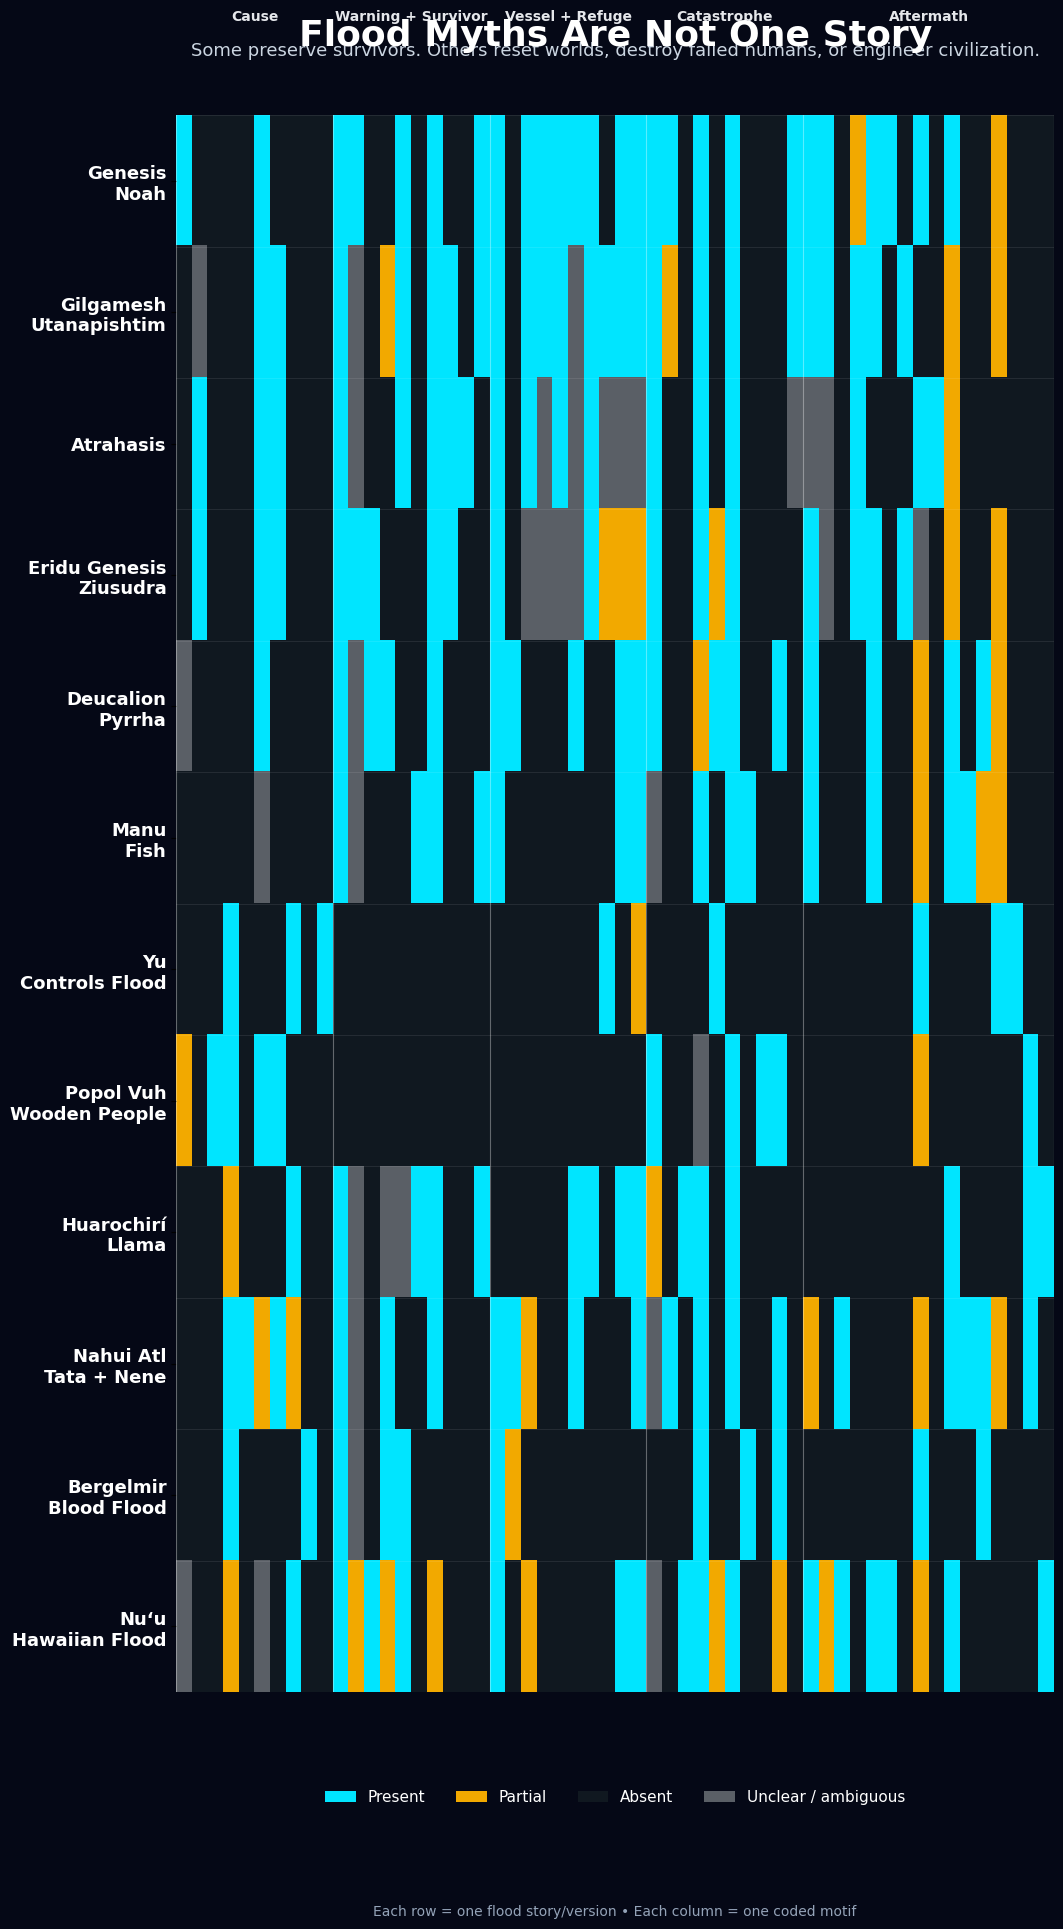

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/youtube_expanded_motif_barcode_v0_1.png')

In [9]:
expanded_barcode_path = OUTPUT_DIR / "youtube_expanded_motif_barcode_v0_1.png"

make_motif_barcode(
    plot_df=df,
    title="Flood Myths Are Not One Story",
    subtitle="Some preserve survivors. Others reset worlds, destroy failed humans, or engineer civilization.",
    output_path=expanded_barcode_path,
    figsize=(10.8, 19.2),
)

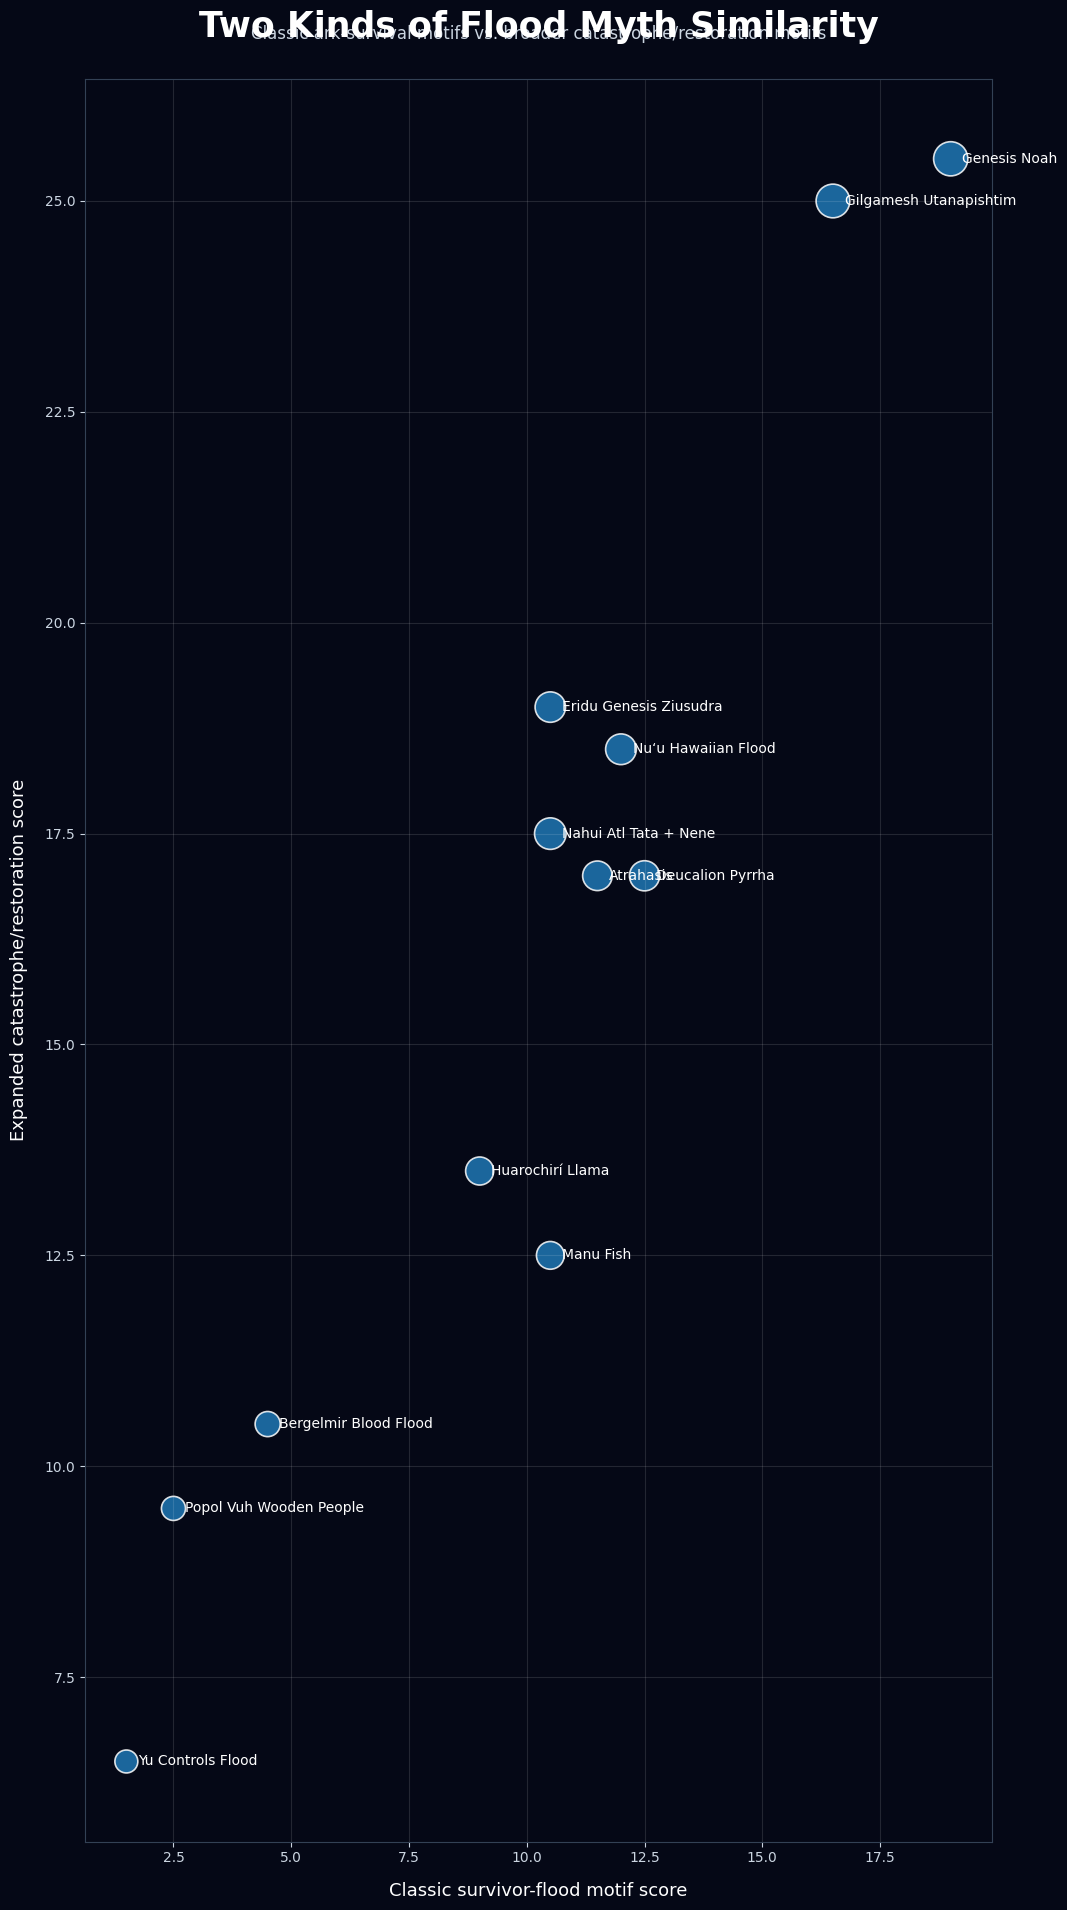

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/youtube_story_type_scatter_v0_1.png')

In [10]:
scatter_df = df.copy()

fig, ax = plt.subplots(figsize=(10.8, 19.2))
fig.patch.set_facecolor("#050816")
ax.set_facecolor("#050816")

x = scatter_df["core_survivor_package_score"]
y = scatter_df["expanded_flood_catastrophe_score"]
sizes = 120 + scatter_df["present_motif_score"] * 18

ax.scatter(
    x,
    y,
    s=sizes,
    alpha=0.85,
    edgecolors="white",
    linewidths=1.2,
)

for _, row in scatter_df.iterrows():
    ax.text(
        row["core_survivor_package_score"] + 0.25,
        row["expanded_flood_catastrophe_score"],
        row["short_label"].replace("\n", " "),
        fontsize=10,
        color="white",
        va="center",
    )

ax.set_title(
    "Two Kinds of Flood Myth Similarity",
    fontsize=25,
    color="white",
    fontweight="bold",
    pad=30,
)

ax.text(
    0.5,
    1.02,
    "Classic ark-survival motifs vs. broader catastrophe/restoration motifs",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=12,
    color="#CBD5E1",
)

ax.set_xlabel("Classic survivor-flood motif score", fontsize=13, color="white", labelpad=12)
ax.set_ylabel("Expanded catastrophe/restoration score", fontsize=13, color="white", labelpad=12)

ax.tick_params(colors="#CBD5E1")

ax.grid(color="white", alpha=0.12)

for spine in ax.spines.values():
    spine.set_color("#334155")

scatter_path = OUTPUT_DIR / "youtube_story_type_scatter_v0_1.png"
plt.tight_layout()
plt.savefig(scatter_path, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

scatter_path

In [11]:
top_pairs = pd.read_csv(TOP_PAIRS_PATH).head(10)

top_pairs["pair_label"] = (
    top_pairs["story_a"].str.replace(" / ", " / ", regex=False)
    + "\n+\n"
    + top_pairs["story_b"].str.replace(" / ", " / ", regex=False)
)

top_pairs

,story_a,story_b,similarity,pair_label
0,Genesis Flood / Noah,Gilgamesh Tablet XI / Utanapishtim,0.806167,Genesis Flood / Noah\n+\nGilgamesh Tablet XI /...
1,Gilgamesh Tablet XI / Utanapishtim,Eridu Genesis / Ziusudra,0.743985,Gilgamesh Tablet XI / Utanapishtim\n+\nEridu G...
2,Gilgamesh Tablet XI / Utanapishtim,Atrahasis Flood,0.667135,Gilgamesh Tablet XI / Utanapishtim\n+\nAtrahas...
3,Atrahasis Flood,Eridu Genesis / Ziusudra,0.666682,Atrahasis Flood\n+\nEridu Genesis / Ziusudra
4,Deucalion and Pyrrha,Nahui Atl / Tata and Nene,0.663080,Deucalion and Pyrrha\n+\nNahui Atl / Tata and ...
5,Deucalion and Pyrrha,Nuʻu and the Hawaiian Flood,0.635193,Deucalion and Pyrrha\n+\nNuʻu and the Hawaiian...
6,Deucalion and Pyrrha,Manu and the Fish,0.631383,Deucalion and Pyrrha\n+\nManu and the Fish
7,Eridu Genesis / Ziusudra,Deucalion and Pyrrha,0.630887,Eridu Genesis / Ziusudra\n+\nDeucalion and Pyrrha
8,Genesis Flood / Noah,Nuʻu and the Hawaiian Flood,0.613874,Genesis Flood / Noah\n+\nNuʻu and the Hawaiian...
9,Genesis Flood / Noah,Eridu Genesis / Ziusudra,0.598421,Genesis Flood / Noah\n+\nEridu Genesis / Ziusudra


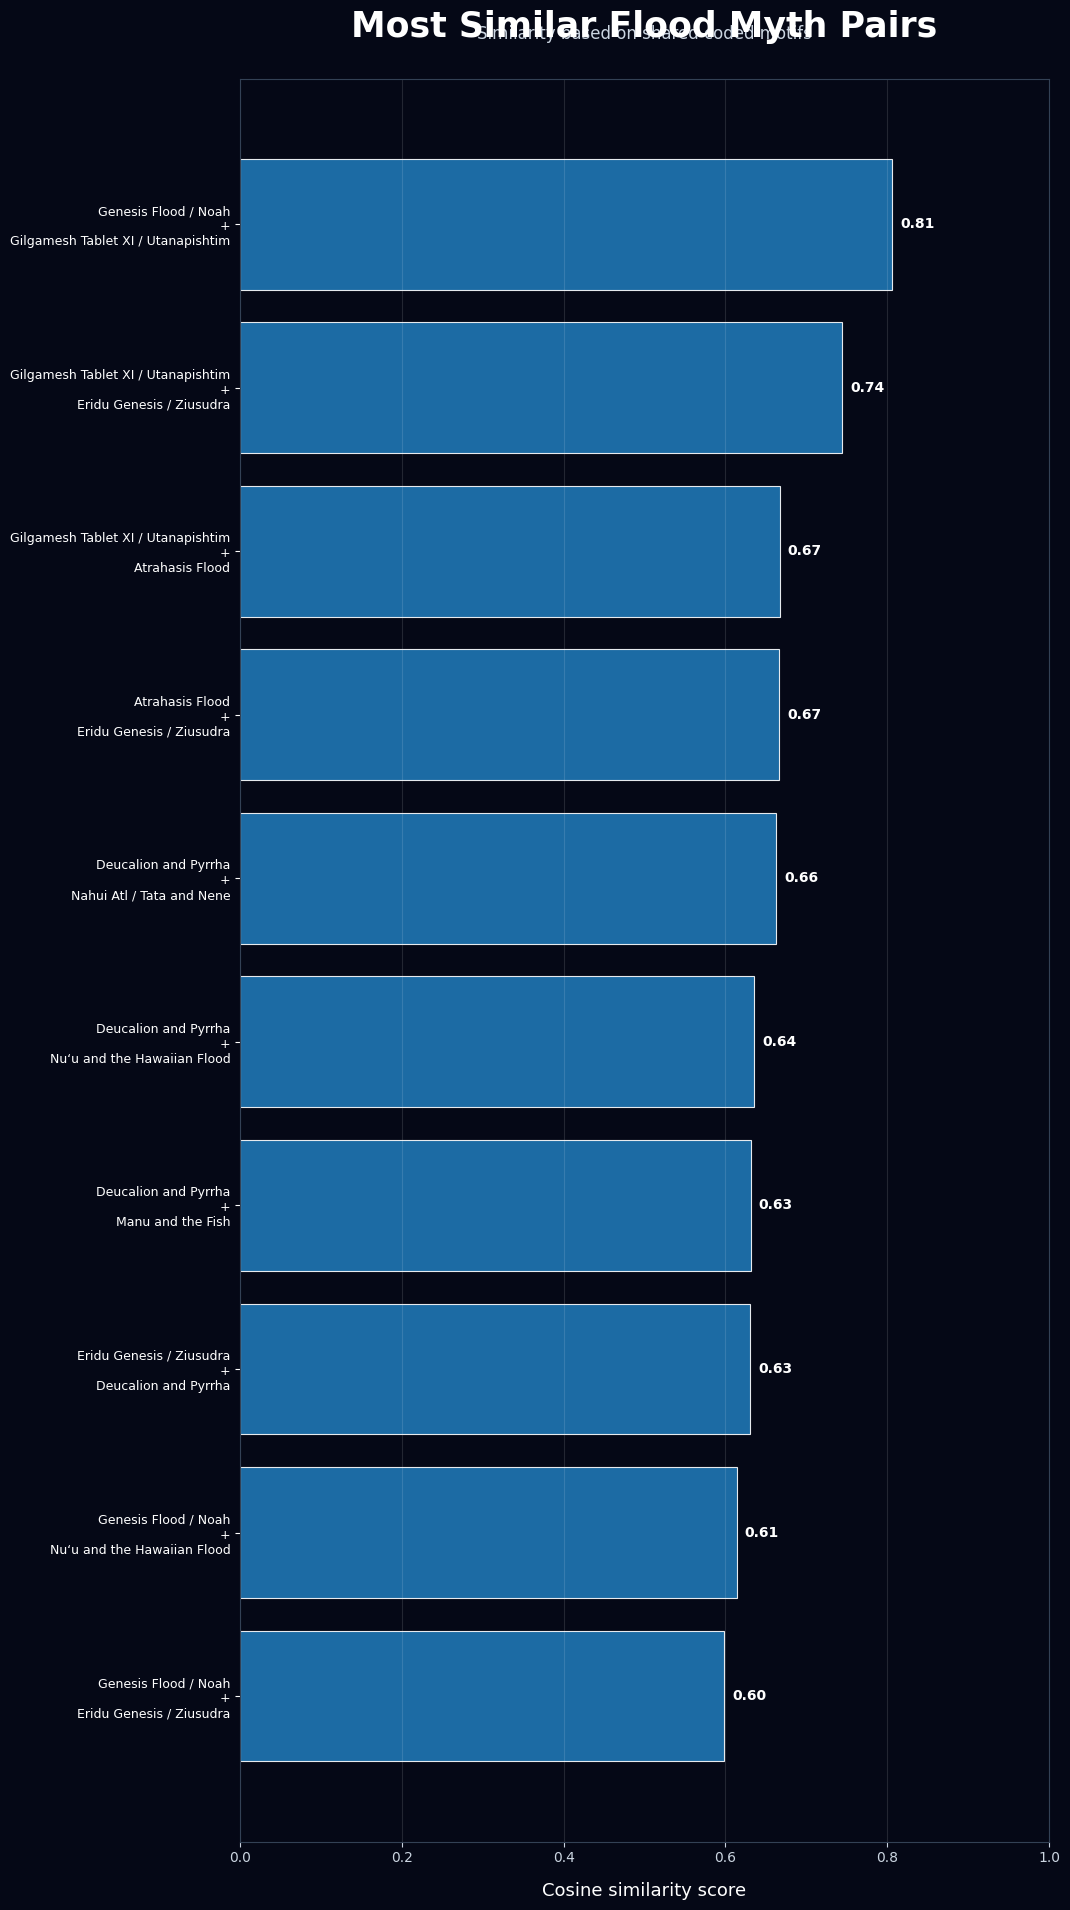

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/youtube_top_similarity_pairs_v0_1.png')

In [12]:
plot_df = top_pairs.sort_values("similarity", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10.8, 19.2))
fig.patch.set_facecolor("#050816")
ax.set_facecolor("#050816")

ax.barh(
    plot_df["pair_label"],
    plot_df["similarity"],
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
)

ax.set_title(
    "Most Similar Flood Myth Pairs",
    fontsize=25,
    color="white",
    fontweight="bold",
    pad=30,
)

ax.text(
    0.5,
    1.02,
    "Similarity based on shared coded motifs",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=12,
    color="#CBD5E1",
)

ax.set_xlabel("Cosine similarity score", fontsize=13, color="white", labelpad=12)
ax.tick_params(axis="x", colors="#CBD5E1")
ax.tick_params(axis="y", colors="white", labelsize=9)

ax.set_xlim(0, 1)

ax.grid(axis="x", color="white", alpha=0.12)

for spine in ax.spines.values():
    spine.set_color("#334155")

for i, value in enumerate(plot_df["similarity"]):
    ax.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

top_pairs_path = OUTPUT_DIR / "youtube_top_similarity_pairs_v0_1.png"

plt.tight_layout()
plt.savefig(top_pairs_path, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

top_pairs_path

In [13]:
story_subtypes = df[
    [
        "story_id",
        "story_name",
        "culture",
        "region",
        "story_type",
        "analysis_group",
        "include_in_core_analysis",
        "core_survivor_package_score",
        "expanded_flood_catastrophe_score",
        "present_motif_score",
        "overall_confidence",
    ]
].copy()

story_subtypes_path = OUTPUT_DIR / "story_subtypes_summary_v0_1.csv"

story_subtypes.to_csv(story_subtypes_path, index=False)

story_subtypes

,story_id,story_name,culture,region,story_type,analysis_group,include_in_core_analysis,core_survivor_package_score,expanded_flood_catastrophe_score,present_motif_score,overall_confidence
0,FM-001,Genesis Flood / Noah,Israelite-Judahite,Levant,survivor-ark flood,biblical_anchor,yes,19.0,25.5,27.0,high
1,FM-002,Gilgamesh Tablet XI / Utanapishtim,Mesopotamian / Babylonian-Akkadian,Mesopotamia,secret-warning ark flood,mesopotamian_cluster,yes,16.5,25.0,26.0,high
2,FM-003,Atrahasis Flood,Mesopotamian / Akkadian-Babylonian,Mesopotamia,noise-cause survivor flood,mesopotamian_cluster,yes,11.5,17.0,18.5,medium
3,FM-004,Eridu Genesis / Ziusudra,Sumerian / Mesopotamian,Mesopotamia,king-priest secret-warning flood,mesopotamian_cluster,yes,10.5,19.0,20.0,medium
4,FM-005,Deucalion and Pyrrha,Greek / Mediterranean,Greece,survivor-chest flood,classic_survivor_flood,yes,12.5,17.0,19.5,high
5,FM-006,Manu and the Fish,Indian / Sanskrit,India,animal-helper ritual-recreation flood,classic_survivor_flood,yes,10.5,12.5,15.5,high
6,FM-007,Yu Controls the Flood,Chinese,China,flood-control civilization-restoration myth,flood_control,no,1.5,6.5,8.5,high
7,FM-008,Popol Vuh / Destruction of the Wooden People,K'iche' Maya / Mesoamerican,Mesoamerica,failed-creation destruction flood,failed_creation,no,2.5,9.5,10.0,high
8,FM-009,Huarochirí / The Llama Warns of the Flood,Andean / Quechua,"Huarochirí, Peru",animal-warning mountain-refuge flood,animal_warning_mountain_refuge,caution,9.0,13.5,16.0,high
9,FM-010,Nahui Atl / Tata and Nene,Nahua / Aztec-Mexica,Central Mexico,world-age flood with survivor transformation,world_age_flood,no,10.5,17.5,22.0,high
